<a href="https://colab.research.google.com/github/rodrigologin0-cpu/Rodrigo-de-Souza-Lima/blob/main/P%C3%AAndulo_Ctrl_Fuzzy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Lógica Fuzzy - Controle do Pêndulo

In [ ]:
# ============================================================
# Controle Fuzzy para Pêndulo Invertido - CartPole-v1
# Código único para Google Colab
# ============================================================

# ------------------------------------------------------------
# 1. Instalações
# ------------------------------------------------------------

!apt-get -qq update
!apt-get -qq install -y xvfb python-opengl > /dev/null
!pip -q install gymnasium[classic-control] scikit-fuzzy pyvirtualdisplay

# ------------------------------------------------------------
# 2. Imports
# ------------------------------------------------------------

import os
import time
import numpy as np
import matplotlib.pyplot as plt

import gymnasium as gym

import skfuzzy as fuzz
from skfuzzy import control as ctrl

from pyvirtualdisplay import Display
from IPython import display

# ------------------------------------------------------------
# 3. Display virtual para renderização no Colab
# ------------------------------------------------------------

if "DISPLAY" not in os.environ:
    virtual_display = Display(visible=0, size=(1400, 900))
    virtual_display.start()

# ------------------------------------------------------------
# 4. Criação do ambiente CartPole
# ------------------------------------------------------------

env = gym.make("CartPole-v1", render_mode="rgb_array")

SEED = 0

obs, info = env.reset(seed=SEED)
env.action_space.seed(SEED)
np.random.seed(SEED)

print("Espaço de ações:", env.action_space)
print("Espaço de observações:", env.observation_space)
print("Maior valor observado:", env.observation_space.high)
print("Menor valor observado:", env.observation_space.low)
print("Formato do vetor de estados:", env.observation_space.shape)

# Estados do CartPole:
# obs[0] = posição do carro [m]
# obs[1] = velocidade do carro [m/s]
# obs[2] = ângulo do pêndulo [rad]
# obs[3] = velocidade angular [rad/s]

# ------------------------------------------------------------
# 5. Criação das variáveis fuzzy
# ------------------------------------------------------------

posicao = ctrl.Antecedent(np.linspace(-4.8, 4.8, 401), "Posicao")
velocidade = ctrl.Antecedent(np.linspace(-5.0, 5.0, 401), "Velocidade")
angulo = ctrl.Antecedent(np.linspace(-0.418, 0.418, 401), "Angulo")
v_angular = ctrl.Antecedent(np.linspace(-5.0, 5.0, 401), "V_angular")

acao = ctrl.Consequent(np.linspace(0, 1, 101), "Acao")

# ------------------------------------------------------------
# 6. Funções de pertinência
# ------------------------------------------------------------

# Posição do carro
posicao["esq"] = fuzz.trapmf(posicao.universe, [-4.8, -4.8, -0.8, -0.15])
posicao["cen"] = fuzz.trimf(posicao.universe, [-0.5, 0.0, 0.5])
posicao["dir"] = fuzz.trapmf(posicao.universe, [0.15, 0.8, 4.8, 4.8])

# Velocidade do carro
velocidade["neg"] = fuzz.trapmf(velocidade.universe, [-5.0, -5.0, -1.0, -0.1])
velocidade["zer"] = fuzz.trimf(velocidade.universe, [-0.5, 0.0, 0.5])
velocidade["pos"] = fuzz.trapmf(velocidade.universe, [0.1, 1.0, 5.0, 5.0])

# Ângulo do pêndulo
# Ângulo negativo: pêndulo inclinado para a esquerda
# Ângulo positivo: pêndulo inclinado para a direita
angulo["neg"] = fuzz.trapmf(angulo.universe, [-0.418, -0.418, -0.04, -0.005])
angulo["zer"] = fuzz.trimf(angulo.universe, [-0.035, 0.0, 0.035])
angulo["pos"] = fuzz.trapmf(angulo.universe, [0.005, 0.04, 0.418, 0.418])

# Velocidade angular
v_angular["neg"] = fuzz.trapmf(v_angular.universe, [-5.0, -5.0, -0.8, -0.05])
v_angular["zer"] = fuzz.trimf(v_angular.universe, [-0.5, 0.0, 0.5])
v_angular["pos"] = fuzz.trapmf(v_angular.universe, [0.05, 0.8, 5.0, 5.0])

# Ação fuzzy
# 0 = empurrar para esquerda
# 1 = empurrar para direita
acao["esq"] = fuzz.trimf(acao.universe, [0.0, 0.0, 0.5])
acao["dir"] = fuzz.trimf(acao.universe, [0.5, 1.0, 1.0])

# ------------------------------------------------------------
# 7. Visualização opcional das funções de pertinência
# ------------------------------------------------------------

MOSTRAR_FUNCOES_PERTINENCIA = False

if MOSTRAR_FUNCOES_PERTINENCIA:
    posicao.view()
    velocidade.view()
    angulo.view()
    v_angular.view()
    acao.view()



Passo: 205
Ação fuzzy: 0.167
Ação discreta: 0
Posição [m]: -0.622
Velocidade [m/s]: 0.947
Ângulo [graus]: -10.634
Velocidade angular [rad/s]: -1.414


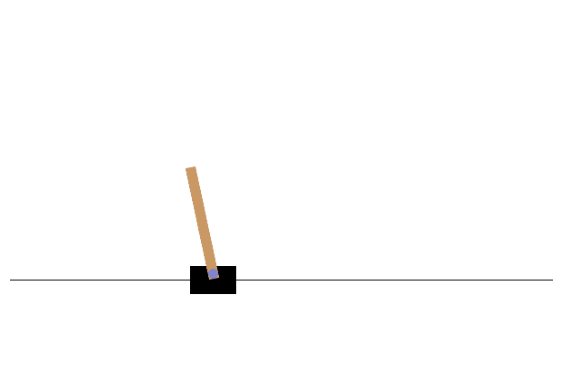

In [29]:
# ------------------------------------------------------------
# 8. Regras fuzzy - versão corrigida e mais robusta
# ------------------------------------------------------------

regras = []

# Regra principal: corrigir o ângulo
regras.append(ctrl.Rule(angulo["neg"], acao["esq"]))
regras.append(ctrl.Rule(angulo["pos"], acao["dir"]))

# Se o ângulo está próximo de zero, usar a velocidade angular
regras.append(ctrl.Rule(angulo["zer"] & v_angular["neg"], acao["esq"]))
regras.append(ctrl.Rule(angulo["zer"] & v_angular["pos"], acao["dir"]))

# Se ângulo e velocidade angular estão próximos de zero,
# usar posição para recentralizar o carro
regras.append(ctrl.Rule(angulo["zer"] & v_angular["zer"] & posicao["esq"], acao["dir"]))
regras.append(ctrl.Rule(angulo["zer"] & v_angular["zer"] & posicao["dir"], acao["esq"]))

# Se está tudo próximo do centro, usar velocidade para amortecer
regras.append(ctrl.Rule(angulo["zer"] & v_angular["zer"] & posicao["cen"] & velocidade["neg"], acao["dir"]))
regras.append(ctrl.Rule(angulo["zer"] & v_angular["zer"] & posicao["cen"] & velocidade["pos"], acao["esq"]))

# REGRA QUE FALTAVA:
# Caso quase ideal: posição central, ângulo zero, velocidade zero e velocidade angular zero
# Como o CartPole não tem ação neutra, escolhemos uma ação padrão.
regras.append(ctrl.Rule(angulo["zer"] & v_angular["zer"] & posicao["cen"] & velocidade["zer"], acao["dir"]))

# Regras adicionais para reforço dinâmico
regras.append(ctrl.Rule(angulo["neg"] & v_angular["neg"], acao["esq"]))
regras.append(ctrl.Rule(angulo["pos"] & v_angular["pos"], acao["dir"]))

regras.append(ctrl.Rule(angulo["neg"] & v_angular["pos"], acao["esq"]))
regras.append(ctrl.Rule(angulo["pos"] & v_angular["neg"], acao["dir"]))

# Sistema fuzzy
Fz_ctrl = ctrl.ControlSystem(regras)
Fz = ctrl.ControlSystemSimulation(Fz_ctrl, flush_after_run=1)

# ------------------------------------------------------------
# 9. Função para limitar entradas no universo fuzzy
# ------------------------------------------------------------

def limitar(valor, minimo, maximo):
    return max(min(valor, maximo), minimo)

# ------------------------------------------------------------
# 10. Função do controlador fuzzy
# ------------------------------------------------------------

def controlador_fuzzy(obs):
    """
    Recebe o vetor de estados do CartPole e retorna:
    - acao_discreta: 0 ou 1
    - acao_fuzzy: valor contínuo entre 0 e 1
    """

    x = obs[0]
    x_dot = obs[1]
    theta = obs[2]
    theta_dot = obs[3]

    # Limita os valores para evitar erro fora do universo fuzzy
    Fz.input["Posicao"] = limitar(x, -4.8, 4.8)
    Fz.input["Velocidade"] = limitar(x_dot, -5.0, 5.0)
    Fz.input["Angulo"] = limitar(theta, -0.418, 0.418)
    Fz.input["V_angular"] = limitar(theta_dot, -5.0, 5.0)

    Fz.compute()

    acao_fuzzy = Fz.output["Acao"]

    if acao_fuzzy < 0.5:
        acao_discreta = 0
    else:
        acao_discreta = 1

    return acao_discreta, acao_fuzzy



In [ ]:
# ------------------------------------------------------------
# 11. Simulação
# ------------------------------------------------------------

MAX_PASSOS = 500
TEMPO_ENTRE_FRAMES = 1
RENDERIZAR = True

obs, info = env.reset(seed=SEED)

historico = {
    "passo": [],
    "posicao": [],
    "velocidade": [],
    "angulo_rad": [],
    "angulo_graus": [],
    "v_angular": [],
    "acao_fuzzy": [],
    "acao_discreta": [],
    "reward": []
}

if RENDERIZAR:
    fig = plt.figure(figsize=(7, 5))
    img = plt.imshow(env.render())
    plt.axis("off")

for passo in range(MAX_PASSOS):

    acao_discreta, acao_fuzzy = controlador_fuzzy(obs)

    nova_obs, reward, terminated, truncated, info = env.step(acao_discreta)

    historico["passo"].append(passo)
    historico["posicao"].append(obs[0])
    historico["velocidade"].append(obs[1])
    historico["angulo_rad"].append(obs[2])
    historico["angulo_graus"].append(obs[2] * 180 / np.pi)
    historico["v_angular"].append(obs[3])
    historico["acao_fuzzy"].append(acao_fuzzy)
    historico["acao_discreta"].append(acao_discreta)
    historico["reward"].append(reward)

    if RENDERIZAR:
        img.set_data(env.render())
        display.display(plt.gcf())
        display.clear_output(wait=True)

        print("Passo:", passo)
        print("Ação fuzzy:", round(acao_fuzzy, 3))
        print("Ação discreta:", acao_discreta)
        print("Posição [m]:", round(obs[0], 3))
        print("Velocidade [m/s]:", round(obs[1], 3))
        print("Ângulo [graus]:", round(obs[2] * 180 / np.pi, 3))
        print("Velocidade angular [rad/s]:", round(obs[3], 3))

        time.sleep(TEMPO_ENTRE_FRAMES)

    obs = nova_obs

    if terminated or truncated:
        break

env.close()




Passo: 86
Ação fuzzy: 0.361
Ação discreta: 0
Posição [m]: -0.201
Velocidade [m/s]: -0.014
Ângulo [graus]: -1.582
Velocidade angular [rad/s]: -0.249


In [28]:
# ------------------------------------------------------------
# 12. Resultado final
# ------------------------------------------------------------

total_passos = len(historico["passo"])
retorno_total = sum(historico["reward"])

print("\n================ RESULTADO FINAL ================")
print("Passos sobrevividos:", total_passos)
print("Retorno total:", retorno_total)
print("Posição final [m]:", obs[0])
print("Ângulo final [graus]:", obs[2] * 180 / np.pi)

if total_passos >= 500:
    print("Resultado: controlador estabilizou o pêndulo até o limite máximo do episódio.")
else:
    print("Resultado: episódio terminou antes do limite máximo.")



================ RESULTADO FINAL ================
Passos sobrevividos: 206
Retorno total: 206.0
Posição final [m]: -0.6027259
Ângulo final [graus]: -12.253642
Resultado: episódio terminou antes do limite máximo.


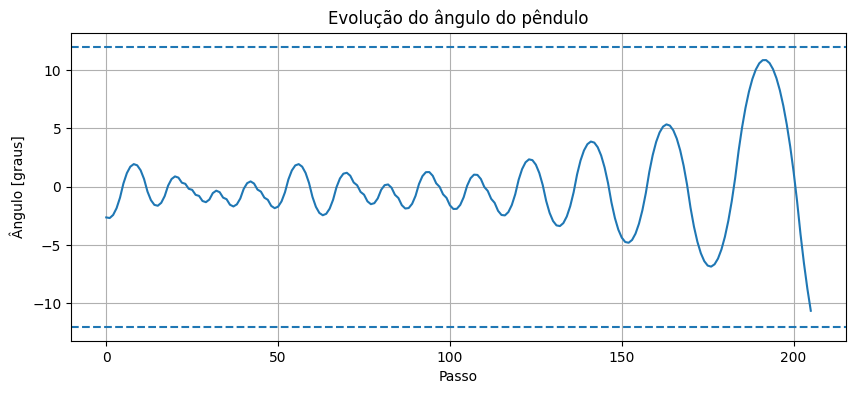

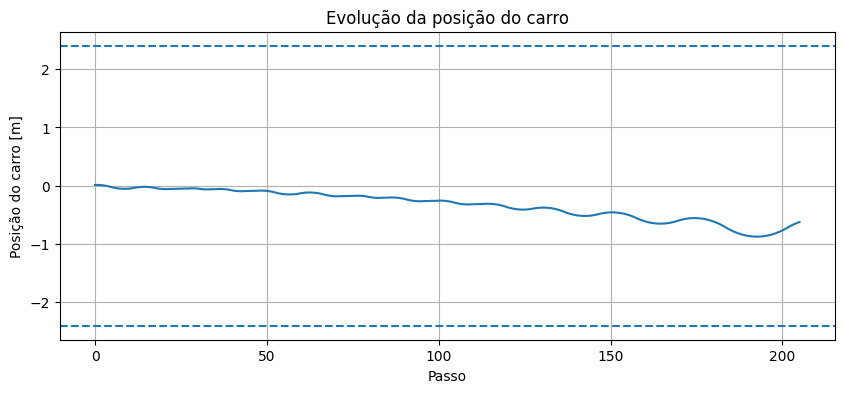

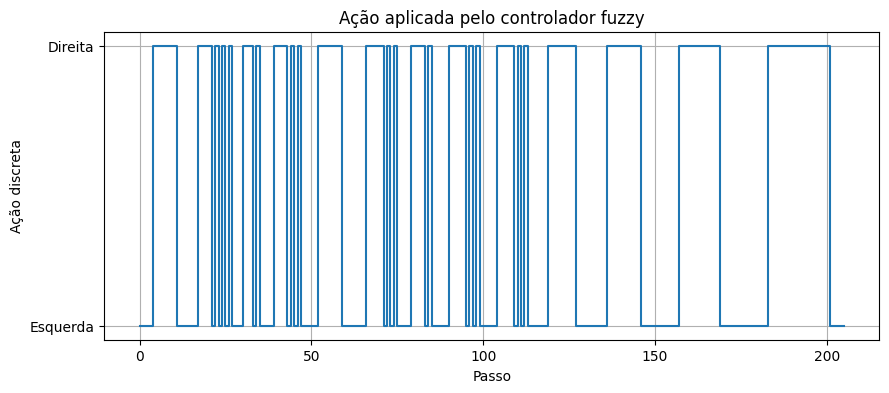

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


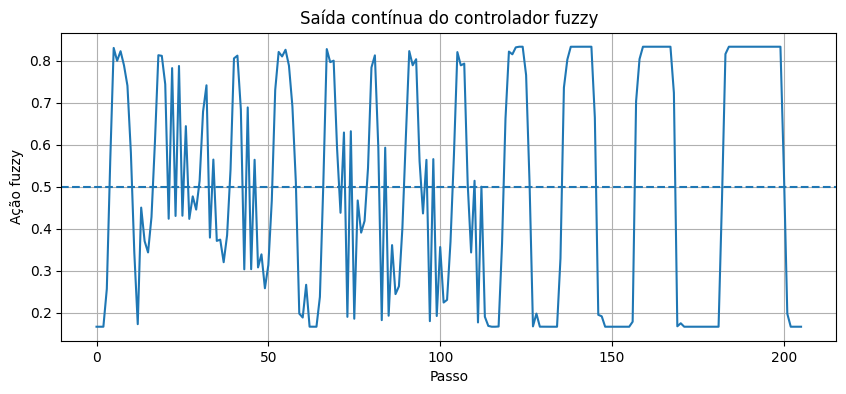

In [25]:
# ------------------------------------------------------------
# 13. Gráficos finais
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))
plt.plot(historico["passo"], historico["angulo_graus"])
plt.axhline(12, linestyle="--")
plt.axhline(-12, linestyle="--")
plt.xlabel("Passo")
plt.ylabel("Ângulo [graus]")
plt.title("Evolução do ângulo do pêndulo")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(historico["passo"], historico["posicao"])
plt.axhline(2.4, linestyle="--")
plt.axhline(-2.4, linestyle="--")
plt.xlabel("Passo")
plt.ylabel("Posição do carro [m]")
plt.title("Evolução da posição do carro")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.step(historico["passo"], historico["acao_discreta"], where="post")
plt.xlabel("Passo")
plt.ylabel("Ação discreta")
plt.title("Ação aplicada pelo controlador fuzzy")
plt.yticks([0, 1], ["Esquerda", "Direita"])
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(historico["passo"], historico["acao_fuzzy"])
plt.axhline(0.5, linestyle="--")
plt.xlabel("Passo")
plt.ylabel("Ação fuzzy")
plt.title("Saída contínua do controlador fuzzy")
plt.grid(True)
plt.show()